<a href="https://colab.research.google.com/github/lauritaplavi/Clonaci-n-de-google/blob/main/Actividad2AnalisisPandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Laura Plascencia Villalobos
*   MATRÍCULA: A01621031


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [56]:
import pandas as pd
from google.colab import files
from google.colab import drive
drive.mount('/content/drive/')

import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [57]:
ruta_archivo = '/content/cleaned_weather.csv'

# Carga el archivo CSV en un DataFrame llamado 'weather_df'.
weather_df = pd.read_csv(ruta_archivo)
# filas, columnas
print(f"Dimensionalidad del DataFrame: {weather_df.shape}")
# identificadores de columnas originales
print("Identificadores de columnas originales:")
print(weather_df.columns.tolist())
# Renombrar
nuevo_nombre_columnas = [
    'medicion','presion_atmosferica', 'temperatura_celsius','temperatura_kelvin',
    'humedad_relativa','presion_vapor','humedad_especifica','concentracion_vapor',
    'densidad_aire','velocidad_viento','direccion_viento','precipitacion_total',
    'duracion_lluvia'
]
weather_df.columns = nuevo_nombre_columnas

print("\nColumnas renombradas:")
print(weather_df.columns.tolist())

#5 primeros registros
print("\nPrimeros 5 registros del DataFrame:")
display(weather_df.head())

# últimos 5 registros
print("\nÚltimos 5 registros del DataFrame:")
display(weather_df.tail())

#valores faltantes
print("\nValores faltantes por columna:")
display(weather_df.isnull().sum())

Dimensionalidad del DataFrame: (52696, 13)
Identificadores de columnas originales:
['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv', 'wd', 'rain', 'raining']

Columnas renombradas:
['medicion', 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin', 'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor', 'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total', 'duracion_lluvia']

Primeros 5 registros del DataFrame:


,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0



Últimos 5 registros del DataFrame:


,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0



Valores faltantes por columna:


,0
medicion,0
presion_atmosferica,0
temperatura_celsius,0
temperatura_kelvin,0
humedad_relativa,0
presion_vapor,0
humedad_especifica,0
concentracion_vapor,0
densidad_aire,0
velocidad_viento,0


2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [58]:
#Tipo de datos
print("\nTipos de datos originales:")
display(weather_df.info())

#Cambiar la columna de "medicion" a datetime
#errors='coerce' para convertir los valores que no coincidan al formato especificado en NaT
weather_df['medicion'] = pd.to_datetime(weather_df['medicion'], format='%d/%m/%y %H:%M', errors='coerce')
print("\nTipos de datos después de la conversión de 'medicion':")
display(weather_df.info())

#columnas adicionales separando "medición" en "fecha" y "hora"
weather_df['fecha'] = weather_df['medicion'].dt.date
weather_df['hora'] = weather_df['medicion'].dt.time

print("\nDataFrame con nuevas columnas 'fecha' y 'hora':")
display(weather_df.head())

print("\nTipos de datos finales con 'fecha' y 'hora':")
display(weather_df.info())


Tipos de datos originales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   medicion             52696 non-null  object 
 1   presion_atmosferica  52696 non-null  float64
 2   temperatura_celsius  52696 non-null  float64
 3   temperatura_kelvin   52696 non-null  float64
 4   humedad_relativa     52696 non-null  float64
 5   presion_vapor        52696 non-null  float64
 6   humedad_especifica   52696 non-null  float64
 7   concentracion_vapor  52696 non-null  float64
 8   densidad_aire        52696 non-null  float64
 9   velocidad_viento     52696 non-null  float64
 10  direccion_viento     52696 non-null  float64
 11  precipitacion_total  52696 non-null  float64
 12  duracion_lluvia      52696 non-null  int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 5.2+ MB


None


Tipos de datos después de la conversión de 'medicion':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   medicion             52696 non-null  datetime64[ns]
 1   presion_atmosferica  52696 non-null  float64       
 2   temperatura_celsius  52696 non-null  float64       
 3   temperatura_kelvin   52696 non-null  float64       
 4   humedad_relativa     52696 non-null  float64       
 5   presion_vapor        52696 non-null  float64       
 6   humedad_especifica   52696 non-null  float64       
 7   concentracion_vapor  52696 non-null  float64       
 8   densidad_aire        52696 non-null  float64       
 9   velocidad_viento     52696 non-null  float64       
 10  direccion_viento     52696 non-null  float64       
 11  precipitacion_total  52696 non-null  float64       
 12  duracion_lluvia      52696 non-n

None


DataFrame con nuevas columnas 'fecha' y 'hora':


,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
0,2020-01-01 00:10:00,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0,2020-01-01,00:10:00
1,2020-01-01 00:20:00,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0,2020-01-01,00:20:00
2,2020-01-01 00:30:00,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0,2020-01-01,00:30:00
3,2020-01-01 00:40:00,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0,2020-01-01,00:40:00
4,2020-01-01 00:50:00,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0,2020-01-01,00:50:00



Tipos de datos finales con 'fecha' y 'hora':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52696 entries, 0 to 52695
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   medicion             52696 non-null  datetime64[ns]
 1   presion_atmosferica  52696 non-null  float64       
 2   temperatura_celsius  52696 non-null  float64       
 3   temperatura_kelvin   52696 non-null  float64       
 4   humedad_relativa     52696 non-null  float64       
 5   presion_vapor        52696 non-null  float64       
 6   humedad_especifica   52696 non-null  float64       
 7   concentracion_vapor  52696 non-null  float64       
 8   densidad_aire        52696 non-null  float64       
 9   velocidad_viento     52696 non-null  float64       
 10  direccion_viento     52696 non-null  float64       
 11  precipitacion_total  52696 non-null  float64       
 12  duracion_lluvia      52696 non-null  int64

None

3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [59]:
#filas en el DataFrame
total_filas = len(weather_df)
print(f"Total de filas en el DataFrame: \n {total_filas}")

#número de valores únicos en la columna 'medicion'
valores_unicos_medicion = weather_df['medicion'].nunique()
print(f"Cantidad de valores únicos en 'medicion': \n {valores_unicos_medicion}")

#checa si la columna de 'medicion' tiene un valor menos que el número total de filas
if valores_unicos_medicion < total_filas:
    print(f"La columna 'medicion' tiene {total_filas - valores_unicos_medicion} valor(es) menos que el número total de filas. Esto indica la presencia de mediciones duplicadas.")

    #Detecta las mediciones duplicadas
    mediciones_duplicadas = weather_df[weather_df.duplicated(subset=['medicion'], keep=False)]
    print("\nLas siguientes mediciones en la columna 'medicion' están duplicadas:")
    display(mediciones_duplicadas.sort_values(by='medicion'))
    #comprueba si las demás columnas también contienen los mismos valores y eliminar duplicados
    print("\nVerificando si las duplicadas son exactas en todas las columnas y eliminando una de ellas...")

    initial_shape = weather_df.shape
    weather_df.drop_duplicates(subset=['medicion'], inplace=True, keep='first')
    final_shape = weather_df.shape

    print(f"Dimensionalidad del DataFrame antes de eliminar duplicados: {initial_shape}")
    print(f"Dimensionalidad del DataFrame después de eliminar duplicados: {final_shape}")

    if initial_shape[0] > final_shape[0]:
        print("Se eliminó un registro duplicado basado en la columna 'medicion'.")
    else:
        print("No se eliminaron registros, lo que significa que las filas duplicadas en 'medicion' tenían diferencias en otras columnas o ya se había eliminado en una ejecución anterior.")

else:
    print("La columna 'medicion' tiene un número de valores únicos igual al total de filas. No se encontraron mediciones duplicadas en esta columna.")

Total de filas en el DataFrame: 
 52696
Cantidad de valores únicos en 'medicion': 
 52695
La columna 'medicion' tiene 1 valor(es) menos que el número total de filas. Esto indica la presencia de mediciones duplicadas.

Las siguientes mediciones en la columna 'medicion' están duplicadas:


,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
19043,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00



Verificando si las duplicadas son exactas en todas las columnas y eliminando una de ellas...
Dimensionalidad del DataFrame antes de eliminar duplicados: (52696, 15)
Dimensionalidad del DataFrame después de eliminar duplicados: (52695, 15)
Se eliminó un registro duplicado basado en la columna 'medicion'.


4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [60]:
# Imprimir la cantidad de valores únicos por columna
print("\n Cantidad de valores únicos por columna (después de eliminar duplicados)")
for column in weather_df.columns:
    print(f"Columna '{column}': {weather_df[column].nunique()} valores únicos")

# 144 horas diferentes
print("\n Explicación del ¿por qué? de las 144 horas diferentes")
print("Los datos meteorológicos son registrados cada 10 minutos. En una hora hay 60 minutos, lo que significa 6 mediciones por hora (60 minutos / 10 minutos/medición = 6). En un día completo (24 horas), esto resulta en 24 horas * 6 mediciones/hora = 144 mediciones únicas por día. Por lo tanto, la columna 'hora' contiene 144 valores únicos, que corresponden a cada intervalo de 10 minutos en un período de 24 horas.")

# Fechas en las que faltan mediciones
print("\n Identificación de mediciones faltantes")

# Reconstrucción columna 'medicion' temporalmente a partir de 'fecha' y 'hora'
weather_df['medicion_reconstructed'] = pd.to_datetime(weather_df['fecha'].astype(str) + ' ' + weather_df['hora'].astype(str))

# Obtener el rango de fechas y horas presentes en el DataFrame con columna reconstruida
min_medicion = weather_df['medicion_reconstructed'].min()
max_medicion = weather_df['medicion_reconstructed'].max()

#rango de fechas y horas completo connfrecuencia = 10 minutos
rango_completo = pd.date_range(start=min_medicion, end=max_medicion, freq='10min')

#mediciones existentes en un set (hacer más eficiente la busqueda)
mediciones_existentes = set(weather_df['medicion_reconstructed'])

#find mediciones faltantes
mediciones_faltantes = sorted(list(set(rango_completo) - mediciones_existentes))

if mediciones_faltantes:
    print(f"Se encontraron {len(mediciones_faltantes)} mediciones faltantes en el rango de tiempo del DataFrame. Aquí algunos ejemplos:")
    for i, ts in enumerate(mediciones_faltantes):
        if i < 10: # Mostrar solo los primeros 10
            print(f"- {ts}")
        elif i == 10:
            print("... y {len(mediciones_faltantes) - 10} más.")
            break

    # Mostrar un resumen por fecha si hay muchas faltantes
    if len(mediciones_faltantes) > 20:
        fechas_con_faltantes = pd.Series(mediciones_faltantes).dt.date.unique()
        print(f"\nLas mediciones faltantes se distribuyen en {len(fechas_con_faltantes)} fechas. Algunas de estas fechas son:")
        for i, date_val in enumerate(fechas_con_faltantes):
            if i < 5:
                print(f"- {date_val}")
            elif i == 5:
                print("... y {len(fechas_con_faltantes) - 5} fechas más.")
                break

else:
    print("No se encontraron mediciones faltantes en el rango de tiempo del DataFrame (con una frecuencia de 10 minutos).")

#eliminar la columna 'medicion_reconstructed' era util para análisis temporalmente
weather_df.drop('medicion_reconstructed', axis=1, inplace=True)

#Eliminación de los registros que no correspondan al año 2020
print("\n Filtrando registros para el año 2020")
initial_rows = len(weather_df)
final_rows_2020 = len(weather_df)
print(f"Filas actuales en el DataFrame: {final_rows_2020}")

#elimina la columna "medicion"
print("\nEliminando la columna 'medicion'")
print(f"Columnas actuales del DataFrame: {weather_df.columns.tolist()}")
# weather_df.drop('medicion', axis=1, inplace=True) # Comentado para evitar KeyError


 Cantidad de valores únicos por columna (después de eliminar duplicados)
Columna 'medicion': 52695 valores únicos
Columna 'presion_atmosferica': 5052 valores únicos
Columna 'temperatura_celsius': 3680 valores únicos
Columna 'temperatura_kelvin': 3836 valores únicos
Columna 'humedad_relativa': 5494 valores únicos
Columna 'presion_vapor': 2059 valores únicos
Columna 'humedad_especifica': 1337 valores únicos
Columna 'concentracion_vapor': 2087 valores únicos
Columna 'densidad_aire': 14826 valores únicos
Columna 'velocidad_viento': 977 valores únicos
Columna 'direccion_viento': 8099 valores únicos
Columna 'precipitacion_total': 42 valores únicos
Columna 'duracion_lluvia': 61 valores únicos
Columna 'fecha': 367 valores únicos
Columna 'hora': 144 valores únicos

 Explicación del ¿por qué? de las 144 horas diferentes
Los datos meteorológicos son registrados cada 10 minutos. En una hora hay 60 minutos, lo que significa 6 mediciones por hora (60 minutos / 10 minutos/medición = 6). En un día co

5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [61]:
#guardA solo los indicadores de mayor valor
indicadores_diarios = weather_df.groupby('fecha').max(numeric_only=True).reset_index()

print("DataFrame indicadores_diarios (primeros 5 registros):")
display(indicadores_diarios.head())

#Máxima precipitación y a qué fecha pertenece?
max_precipitacion = indicadores_diarios['precipitacion_total'].max()
fecha_max_precipitacion = indicadores_diarios.loc[indicadores_diarios['precipitacion_total'].idxmax(), 'fecha']
print(f"\nLa máxima precipitación fue de {max_precipitacion} mm y ocurrió en la fecha: {fecha_max_precipitacion}")

#3 días con las velocidades de viento más altas registradas?
velocidades_viento_altas = indicadores_diarios.sort_values(by='velocidad_viento', ascending=False).head(3)
print("\nLos tres días con las velocidades de viento más altas registradas fueron:")
for index, row in velocidades_viento_altas.iterrows():
    print(f"Fecha: {row['fecha']}, Velocidad del viento: {row['velocidad_viento']} m/s")

#Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?
dias_condicion = indicadores_diarios[
    (indicadores_diarios['humedad_relativa'] > 90) &
    (indicadores_diarios['temperatura_celsius'] > 30)
]
num_dias_condicion = len(dias_condicion)
print(f"\nNúmero de días que rebasaron el 90% de humedad relativa y los 30° Celsius: {num_dias_condicion}")

DataFrame indicadores_diarios (primeros 5 registros):


,fecha,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0
1,2020-01-02,1004.16,6.47,279.72,93.9,5.57,3.48,5.58,1304.37,2.67,358.8,0.0,0
2,2020-01-03,998.45,8.17,281.80,89.3,9.34,5.86,9.39,1266.97,8.79,336.5,0.2,470
3,2020-01-04,1003.47,6.61,280.15,91.4,8.54,5.36,8.58,1270.10,4.61,354.7,1.0,600
4,2020-01-05,1009.07,4.43,277.01,85.3,6.44,3.99,6.40,1275.47,3.14,274.6,0.0,0



La máxima precipitación fue de 11.2 mm y ocurrió en la fecha: 2020-06-16

Los tres días con las velocidades de viento más altas registradas fueron:
Fecha: 2020-02-10, Velocidad del viento: 13.77 m/s
Fecha: 2020-02-16, Velocidad del viento: 13.0 m/s
Fecha: 2020-02-09, Velocidad del viento: 12.52 m/s

Número de días que rebasaron el 90% de humedad relativa y los 30° Celsius: 5


6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [62]:
estadisticas_diarias = indicadores_diarios.describe()
display(estadisticas_diarias)

#¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
desc_vapor = estadisticas_diarias.loc['std', 'concentracion_vapor']
print(f"\nLa desviación estándar de la concentración de vapor es: \n {desc_vapor:.2f}")
print("Esto indica la dispersión o variabilidad de la concentración de vapor alrededor de su promedio diario a lo largo del año. Un valor más alto significaría que la concentración de vapor varía más de un día a otro, mientras que un valor más bajo indica mayor consistencia.")

#¿Cuál es la mediana de la presión atmosférica y qué significa?
mediana_presion = estadisticas_diarias.loc['50%', 'presion_atmosferica']
print(f"\nLa mediana de la presión atmosférica es: \n {mediana_presion:.2f}")
print("La mediana representa el valor central de la presión atmosférica. El 50% de los días tuvieron una presión atmosférica igual o inferior a este valor, y el otro 50% tuvieron una presión igual o superior. Es una medida robusta de la tendencia central, menos afectada por valores extremos que la media.")

#¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?
tercer_cuartil_lluvia = estadisticas_diarias.loc['75%', 'duracion_lluvia']
print(f"\nEl tercer cuartil de la duración de la lluvia es:\n {tercer_cuartil_lluvia:.2f}")
print("Este valor indica que el 75% de los días tuvieron una duración de lluvia igual o inferior a {tercer_cuartil_lluvia:.2f} segundos. Se interpreta como el umbral por debajo del cual se encuentra la mayor parte (las tres cuartas partes) de los registros de duración de lluvia diarios, ayudando a entender la distribución superior de los días con lluvia.")

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.00000,367.000000,367.000000
mean,992.937684,15.307439,289.397493,90.863406,11.394223,7.204469,11.523951,1232.631226,5.232425,317.41109,0.313351,239.727520
std,8.566381,7.870443,7.958291,9.199681,4.510839,2.874545,4.576325,32.658138,2.108317,50.79188,0.978519,273.753373
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,0.570000,69.57000,0.000000,0.000000
25%,987.915000,8.815000,282.715000,85.350000,7.630000,4.825000,7.735000,1207.750000,3.660000,278.80000,0.000000,0.000000
50%,993.300000,15.040000,289.120000,93.200000,10.710000,6.700000,10.730000,1231.720000,4.880000,346.60000,0.000000,0.000000
75%,998.415000,21.690000,295.945000,99.900000,14.455000,9.170000,14.670000,1256.035000,6.480000,357.30000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.00000,11.200000,600.000000



La desviación estándar de la concentración de vapor es: 
 4.58
Esto indica la dispersión o variabilidad de la concentración de vapor alrededor de su promedio diario a lo largo del año. Un valor más alto significaría que la concentración de vapor varía más de un día a otro, mientras que un valor más bajo indica mayor consistencia.

La mediana de la presión atmosférica es: 
 993.30
La mediana representa el valor central de la presión atmosférica. El 50% de los días tuvieron una presión atmosférica igual o inferior a este valor, y el otro 50% tuvieron una presión igual o superior. Es una medida robusta de la tendencia central, menos afectada por valores extremos que la media.

El tercer cuartil de la duración de la lluvia es:
 600.00
Este valor indica que el 75% de los días tuvieron una duración de lluvia igual o inferior a {tercer_cuartil_lluvia:.2f} segundos. Se interpreta como el umbral por debajo del cual se encuentra la mayor parte (las tres cuartas partes) de los registros de durac

7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

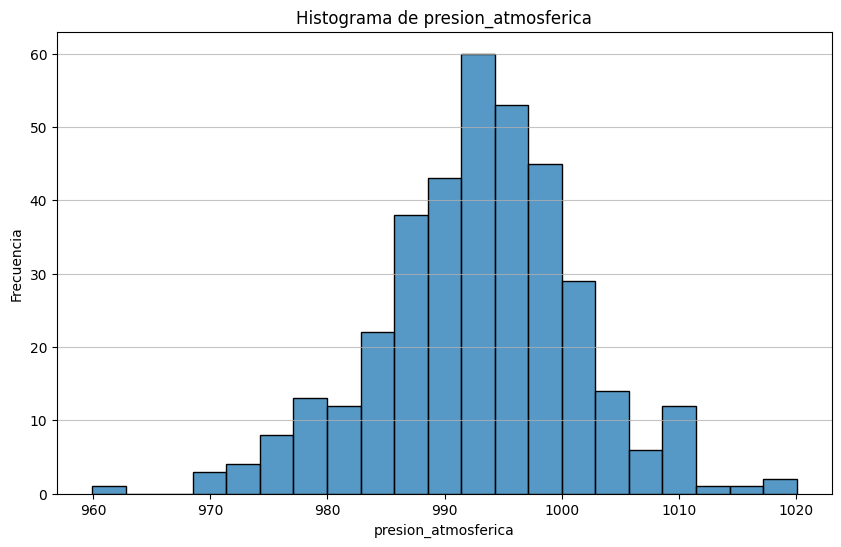

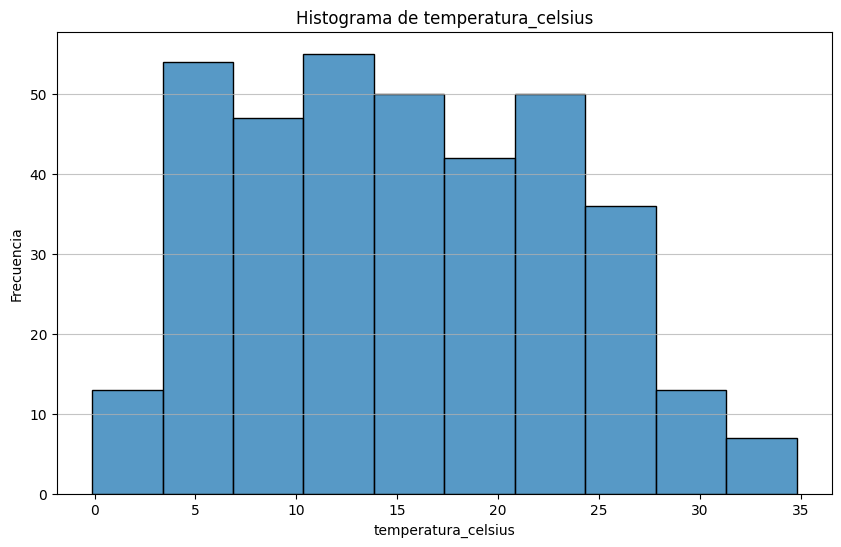

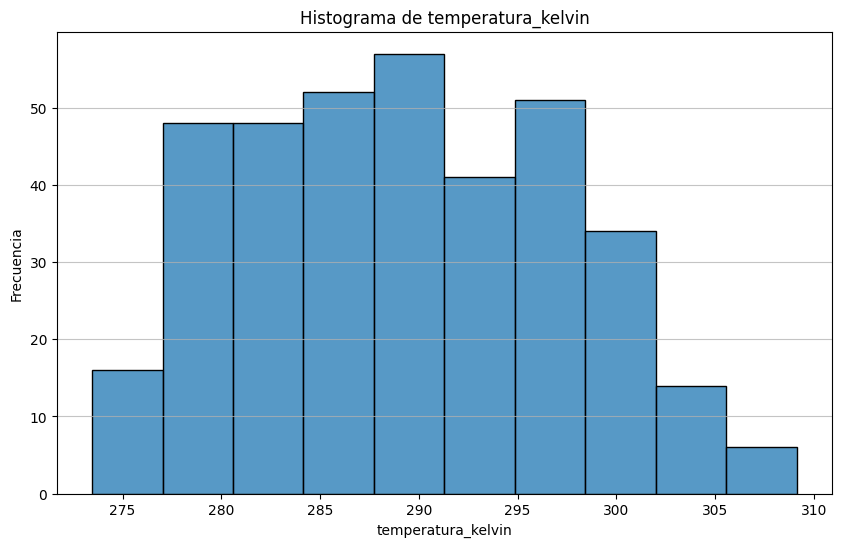

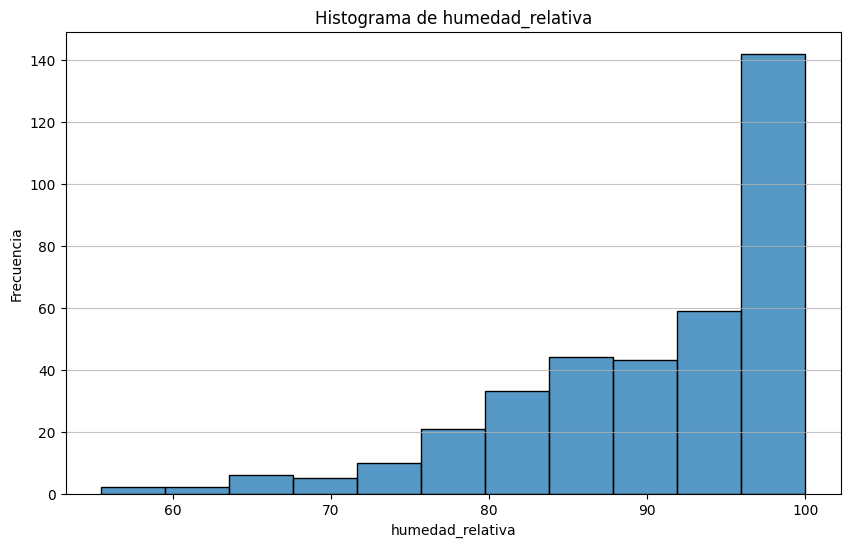

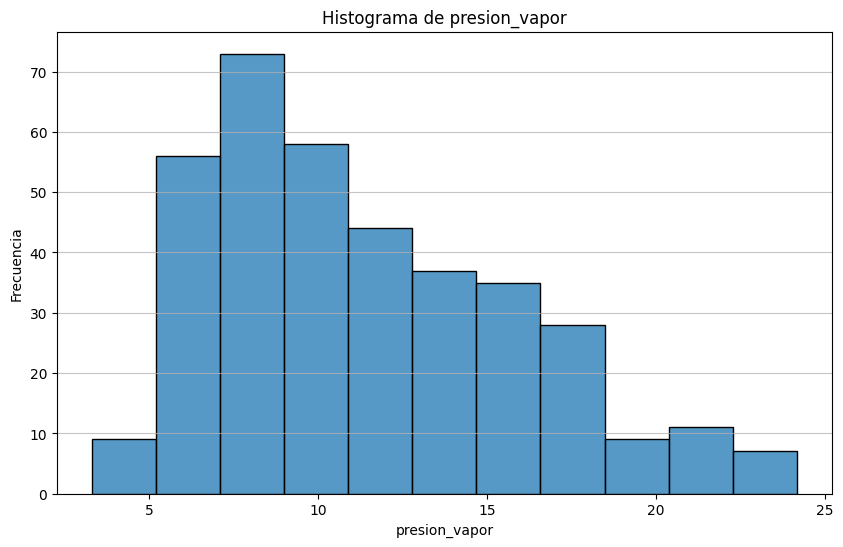

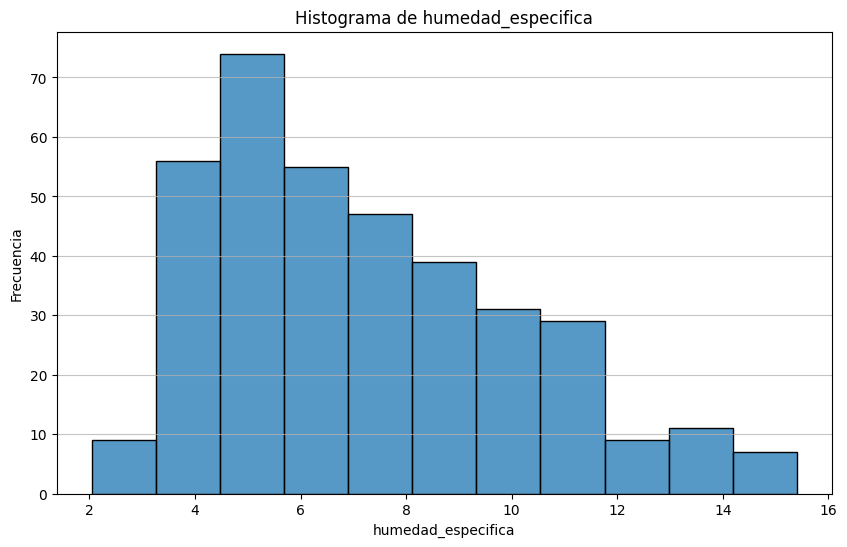

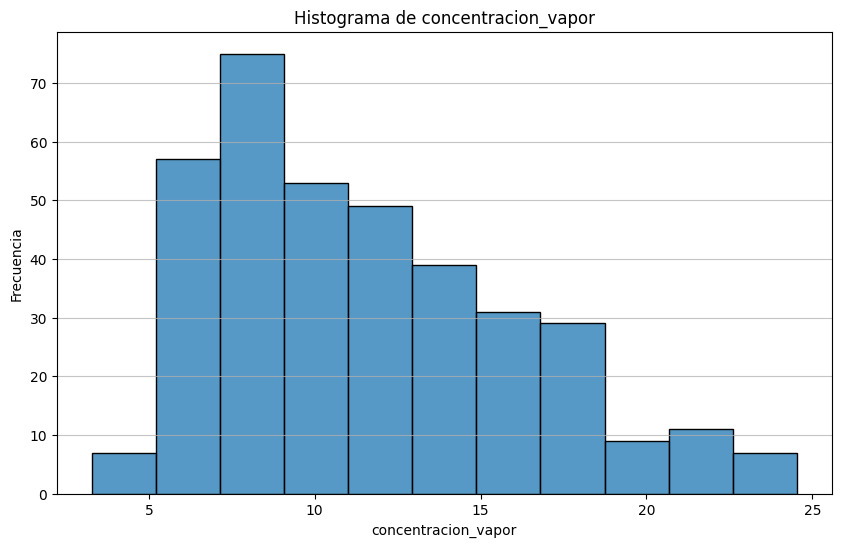

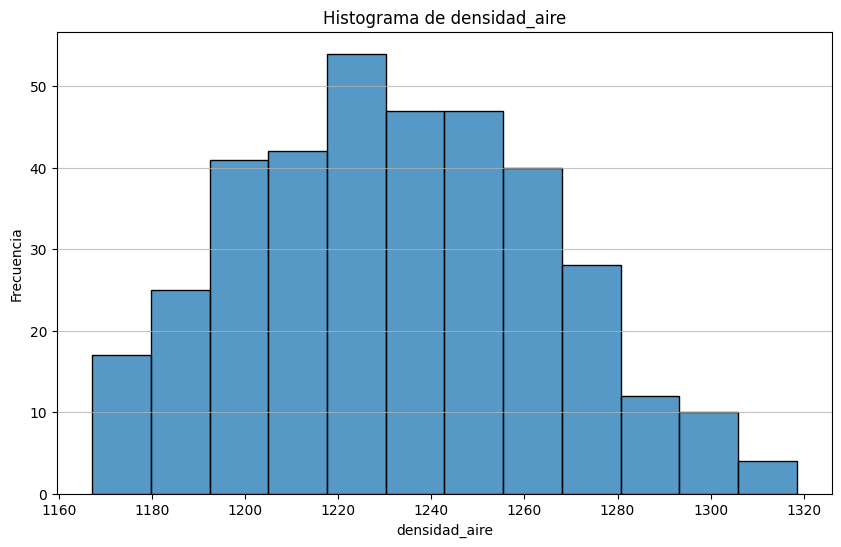

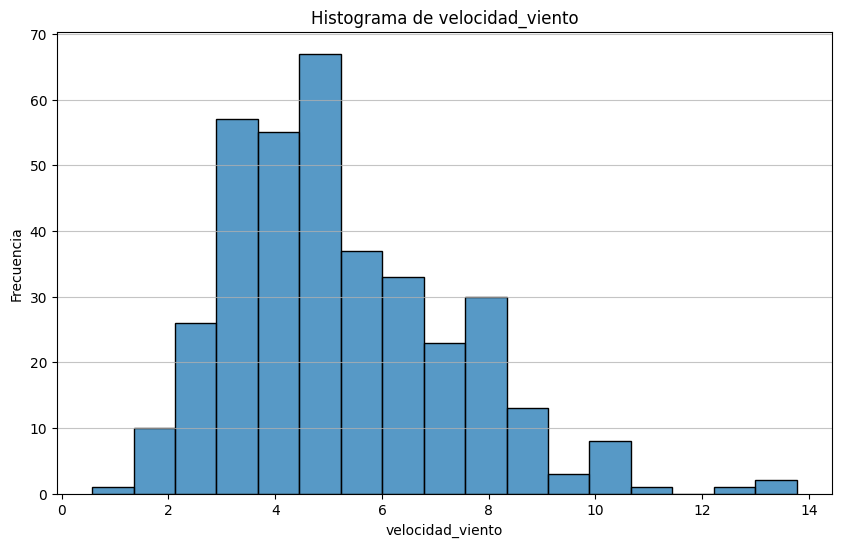

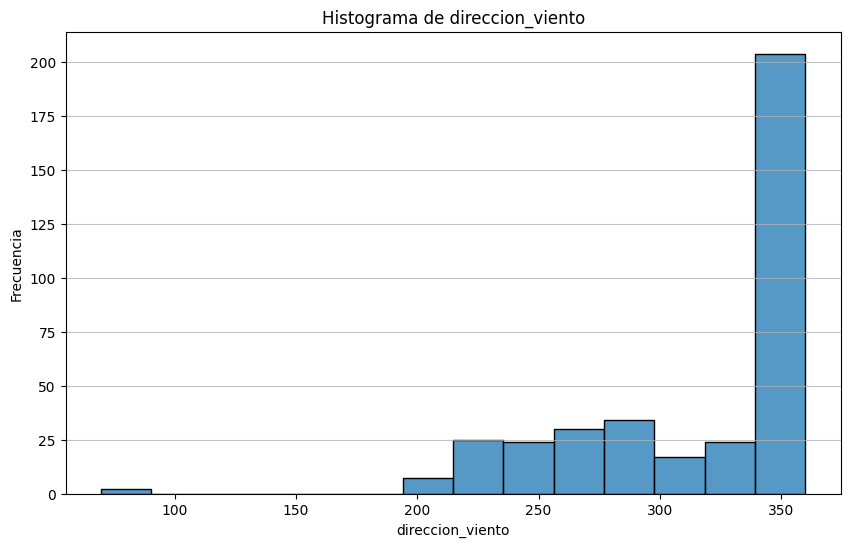

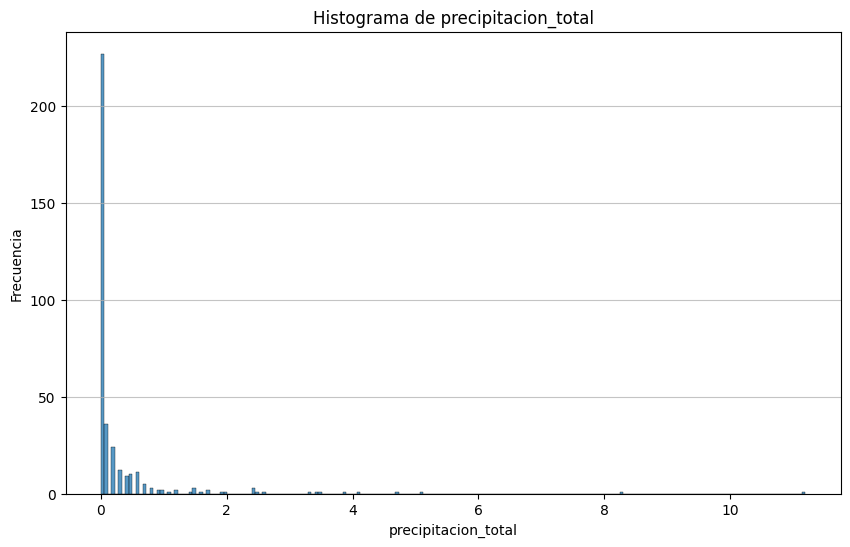

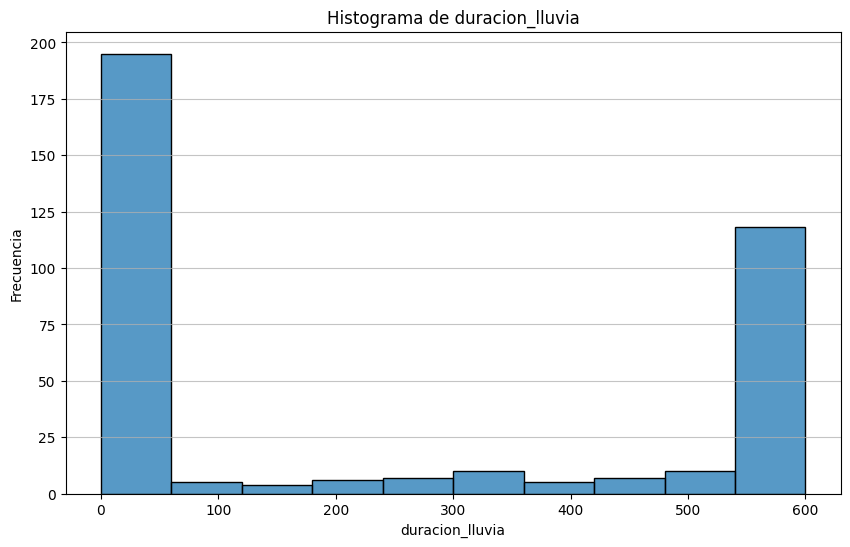

In [63]:
#columnas numéricas del DataFrame indicadores_diarios
columnas_numericas = indicadores_diarios.select_dtypes(include=['number']).columns
#iterar sobre cada columna numérica y dibujar un histograma
for col in columnas_numericas:
    plt.figure(figsize=(10, 6))
    sns.histplot(indicadores_diarios[col]) # se puede añadir kde=True que añade la curva de densidad de probabilidad
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
    plt.show()


8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [64]:
#asegurando que 'fecha' sea un tipo de dato datetime
indicadores_diarios['fecha'] = pd.to_datetime(indicadores_diarios['fecha'])
# Nueva columna 'mes'
indicadores_diarios['mes'] = indicadores_diarios['fecha'].dt.month
# Calcula los promedios mensuales para las columnas especificadas
indicadores_mensuales = indicadores_diarios.groupby('mes')[['humedad_relativa','temperatura_celsius', 'velocidad_viento']].mean().reset_index()
print("DataFrame indicadores_mensuales (promedios mensuales):")
display(indicadores_mensuales.head())


DataFrame indicadores_mensuales (promedios mensuales):


,mes,humedad_relativa,temperatura_celsius,velocidad_viento
0,1,89.545625,6.670937,4.892500
1,2,85.719655,8.962414,7.489655
2,3,85.372903,9.683871,6.421290
3,4,80.938667,16.879667,4.997000
4,5,87.464839,17.135484,4.865806


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [65]:
# promedios mensuales utilizando tabla pivote
indicadores_mensuales_pivot = indicadores_diarios.pivot_table(
    index='mes',
    values=['humedad_relativa', 'temperatura_celsius', 'velocidad_viento'],
    aggfunc='mean'
).reset_index()
print("DataFrame indicadores_mensuales_pivot (promedios mensuales):")
display(indicadores_mensuales_pivot.head())

#+ columna 'indice_calor' usando la fórmula de Thom: temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4
indicadores_mensuales_pivot['indice_calor'] = (
    indicadores_mensuales_pivot['temperatura_celsius'] +
    0.33 * indicadores_mensuales_pivot['humedad_relativa'] -
    0.7 * indicadores_mensuales_pivot['velocidad_viento'] - 4
)

print("\nDataFrame indicadores_mensuales_pivot con 'indice_calor' (primeros 5 registros):")
display(indicadores_mensuales_pivot.head())


DataFrame indicadores_mensuales_pivot (promedios mensuales):


,mes,humedad_relativa,temperatura_celsius,velocidad_viento
0,1,89.545625,6.670937,4.892500
1,2,85.719655,8.962414,7.489655
2,3,85.372903,9.683871,6.421290
3,4,80.938667,16.879667,4.997000
4,5,87.464839,17.135484,4.865806



DataFrame indicadores_mensuales_pivot con 'indice_calor' (primeros 5 registros):


,mes,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
0,1,89.545625,6.670937,4.892500,28.796244
1,2,85.719655,8.962414,7.489655,28.007141
2,3,85.372903,9.683871,6.421290,29.362026
3,4,80.938667,16.879667,4.997000,36.091527
4,5,87.464839,17.135484,4.865806,38.592816


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [66]:
#melt()
indicadores_mensuales_melted = indicadores_mensuales_pivot.melt(id_vars=['mes'],
                                                               value_vars=['humedad_relativa', 'temperatura_celsius', 'velocidad_viento', 'indice_calor'],
                                                               var_name='indicador',
                                                               value_name='valor')
print("\nDataFrame usando melt() (primeros 5 registros):")
display(indicadores_mensuales_melted.head())
#stack()'mes' como índice para usar stack en las columnas de interés
indicadores_mensuales_stacked = indicadores_mensuales_pivot.set_index('mes')[['humedad_relativa', 'temperatura_celsius', 'velocidad_viento', 'indice_calor']].stack().reset_index()
indicadores_mensuales_stacked.columns = ['mes', 'indicador', 'valor'] # Renombrar columnas
print("\nDataFrame usando stack() (primeros 5 registros):")
display(indicadores_mensuales_stacked.head())
print("\nDiferencias entre melt() y stack()")
print("Ambas funciones transforman el DataFrame de un formato 'ancho' a un formato 'largo' (o 'ordenado').\n")
print("melt():")
print("Es más explícita y flexible. Permite especificar qué columnas mantener como identificadores (`id_vars`) y cuáles convertir en filas (`value_vars`). Crea dos nuevas columnas por defecto o personalizables: una para los nombres de las variables ('indicador' en este caso) y otra para sus valores ('valor').")
print("Es ideal cuando quieres 'despivotar' un conjunto específico de columnas manteniendo otras intactas.\n")
print("stack(): \nEs más automática y opera sobre los niveles más bajos de las columnas de un MultiIndex (si existen) o sobre las columnas del DataFrame por defecto si no hay MultiIndex.Sin un MultiIndex en las columnas, 'apila' todas las columnas al nivel del índice existente. Para obtener un resultado similar a 'melt()', a menudo es necesario establecer el índice ('mes' en nuestro caso) y luego aplicar 'stack()' y 'reset_index()'. " )
print("La función 'stack()' traslada las columnas a un nuevo nivel del índice del DataFrame, resultando en un MultiIndex. Para que las columnas vuelvan a ser normales, a menudo se usa 'reset_index()' después. En este ejemplo, renombramos las columnas para que coincidieran con la salida de 'melt()' para una comparación más clara.")
print("En conclusión, mientras que ambas logran un formato largo 'melt()' es generalmente más directa para escenarios donde se definen las columnas de 'ID' y 'valor', mientras que 'stack()' es muy útil para manipular y desapilar niveles de un MultiIndex de columnas de forma más automática.")


DataFrame usando melt() (primeros 5 registros):


,mes,indicador,valor
0,1,humedad_relativa,89.545625
1,2,humedad_relativa,85.719655
2,3,humedad_relativa,85.372903
3,4,humedad_relativa,80.938667
4,5,humedad_relativa,87.464839



DataFrame usando stack() (primeros 5 registros):


,mes,indicador,valor
0,1,humedad_relativa,89.545625
1,1,temperatura_celsius,6.670937
2,1,velocidad_viento,4.892500
3,1,indice_calor,28.796244
4,2,humedad_relativa,85.719655



Diferencias entre melt() y stack()
Ambas funciones transforman el DataFrame de un formato 'ancho' a un formato 'largo' (o 'ordenado').

melt():
Es más explícita y flexible. Permite especificar qué columnas mantener como identificadores (`id_vars`) y cuáles convertir en filas (`value_vars`). Crea dos nuevas columnas por defecto o personalizables: una para los nombres de las variables ('indicador' en este caso) y otra para sus valores ('valor').
Es ideal cuando quieres 'despivotar' un conjunto específico de columnas manteniendo otras intactas.

stack(): 
Es más automática y opera sobre los niveles más bajos de las columnas de un MultiIndex (si existen) o sobre las columnas del DataFrame por defecto si no hay MultiIndex.Sin un MultiIndex en las columnas, 'apila' todas las columnas al nivel del índice existente. Para obtener un resultado similar a 'melt()', a menudo es necesario establecer el índice ('mes' en nuestro caso) y luego aplicar 'stack()' y 'reset_index()'. 
La función 'stack()'

### Declaración de uso de IA

*   Google. (2024). *Gemini* [Modelo de lenguaje grande], utilizado para optimizar la visualización de las gráficas. https://gemini.google.com/